In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

In [2]:
root_path = "/home/stefan/ioai-prep/kits/locala/paintings"
seed = 42

# Data

In [3]:
train_df_ = pd.read_csv(f"{root_path}/train.csv")
test_df_ = pd.read_csv(f"{root_path}/test.csv")

# Subtask 1

In [4]:
def compute_aas(df):
    aas = np.zeros(len(df), dtype=int)
    aas += (df["stroke_density"] > 0.7) * 2
    aas += (df["complexity"] > 0.65) * 2
    aas += df["uses_gold_leaf"]
    aas += df["has_signature"]
    aas += ((df["num_colors"] > 65) & (df["colorfulness"] > 0.7)) * 2
    aas -= ((df["contrast"] < 0.4) | (df["brightness"] < 0.45) | (df["brightness"] > 0.75))
    return aas

test_aas = compute_aas(test_df_)
subtask1 = np.where(test_aas >= 5, "Autentic", "Incert")

(array([158.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  82.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

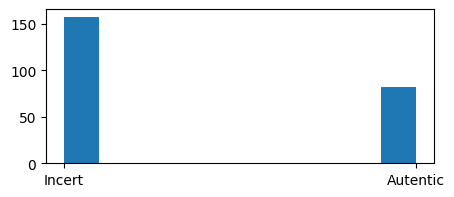

In [5]:
plt.figure(figsize=(5, 2))
plt.hist(subtask1)

# Subtask 2

In [6]:
cluster_cols = ["painter_style_score", "fake_style_score", "complexity", "stroke_density", 
                "colorfulness", "brightness", "contrast", "num_colors", "complexity_x_stroke"]

combined_raw = pd.concat([train_df_, test_df_], ignore_index=True)
combined_raw = combined_raw[cluster_cols]
X_cluster = StandardScaler().fit_transform(combined_raw)

km = KMeans(n_clusters=5, n_init=20, random_state=seed)
all_labels = km.fit_predict(X_cluster)
subtask2 = all_labels[len(train_df_) :]

<Axes: >

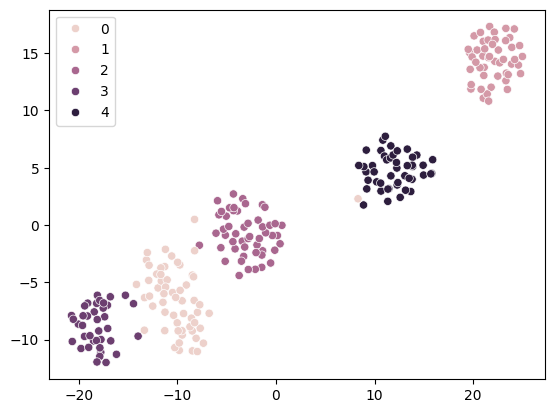

In [7]:
tsne = TSNE(n_components=2, random_state=seed)

xy = tsne.fit_transform(X_cluster[len(train_df_) :])

sns.scatterplot(x=xy[:, 0], y=xy[:, 1], hue=subtask2)

# Subtask 3

In [ ]:
# clusters only for train now - be sure to avoid leakage
cluster_scaler = StandardScaler()
kmeans = KMeans(n_clusters=5, n_init=20, random_state=seed)

X_cluster_train = cluster_scaler.fit_transform(train_df_[cluster_cols])
kmeans.fit(X_cluster_train)


def add_cluster_info(df):
    df = df.copy()
    X_scaled = cluster_scaler.transform(df[cluster_cols])
    labels = kmeans.predict(X_scaled)
    df["cluster_feat"] = labels.astype(str)  # 1st important feature
    return df

In [ ]:
def clean_df(df):
    df = df.copy()
    df = df.drop(["SampleID", "target_price"], axis=1, errors="ignore")

    dims = df["canvas_size"].str.split("x", expand=True).astype(float)
    df["canvas_area"] = dims[0] * dims[1] # 2nd important feature
    df["aspect_ratio"] = dims[0] / dims[1]
    df["dim0"] = dims[0]
    df["dim1"] = dims[1]
    df = df.drop("canvas_size", axis=1)

    cat_cols = df.select_dtypes(include="object").columns
    for col in cat_cols:
        dummy = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df, dummy], axis=1)
        df = df.drop(col, axis=1)

    return df


train_df_mod = add_cluster_info(train_df_)
train_df_mod["AAS"] = compute_aas(train_df_mod)
train_df = clean_df(train_df_mod)
y = train_df_["target_price"]

In [10]:
train_df.head()

,is_oil_painting,num_colors,colorfulness,complexity,brightness,contrast,stroke_density,has_signature,is_framed,uses_gold_leaf,...,art_period_hint_unknown,auction_house_Local,auction_house_Online,auction_house_Sothebys,image_quality_low,image_quality_medium,cluster_feat_1,cluster_feat_2,cluster_feat_3,cluster_feat_4
0,True,71,0.616240,0.755582,0.647338,0.587923,0.702118,True,True,False,...,False,False,True,False,True,False,False,False,True,False
1,True,60,0.660715,0.474923,0.538822,0.599076,0.528112,True,False,False,...,False,False,True,False,True,False,False,False,False,True
2,True,64,0.684877,0.380591,0.608029,0.500152,0.508521,True,False,False,...,False,False,False,True,True,False,False,False,False,True
3,True,56,0.427938,0.581636,0.562086,0.483896,0.550152,True,False,False,...,False,True,False,False,True,False,True,False,False,False
4,True,55,0.481406,0.629780,0.476093,0.493429,0.681710,True,True,False,...,False,True,False,False,False,True,True,False,False,False


In [11]:
train_df.corrwith(y).sort_values(ascending=False)

painter_style_score              0.872265
complexity_x_stroke              0.731622
stroke_density                   0.723110
complexity                       0.696504
AAS                              0.560739
cluster_feat_2                   0.511836
canvas_area                      0.404347
dim0                             0.332505
num_colors                       0.318992
contrast                         0.249758
dim1                             0.215419
is_oil_painting                  0.131228
brightness                       0.130427
brightness_log                   0.123604
colorfulness                     0.097266
cluster_feat_3                   0.072318
has_signature                    0.068622
auction_house_Sothebys           0.066638
uses_gold_leaf                   0.040091
art_period_hint_modern           0.036681
dominant_color_mixed             0.028286
brush_type_thick                 0.024593
brush_type_medium                0.022895
art_period_hint_surrealism       0

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    train_df, y, test_size=0.2, random_state=seed
)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
def evaluate(model):
    cv = cross_val_score(model, X_train, y_train, scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
    cv = cv.mean() + cv.std()

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = mean_absolute_error(preds, y_test)
    return score, -cv

In [15]:
lr = Ridge(alpha=0.1, random_state=seed)

evaluate(lr)

(509.717118577529, 486.3713157460767)

In [16]:
final_scaler = StandardScaler()
X_full = final_scaler.fit_transform(train_df)

final_model = Ridge(alpha=0.1, random_state=seed)
final_model.fit(X_full, y)

Ridge(alpha=0.1, random_state=42)

In [17]:
test_df_mod = add_cluster_info(test_df_)
test_df_mod["AAS"] = compute_aas(test_df_mod)
test_df = clean_df(test_df_mod)

test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

test_df_scaled = final_scaler.transform(test_df)

subtask3 = final_model.predict(test_df_scaled)

(array([14., 21., 15., 31., 28., 35., 38., 40., 15.,  3.]),
 array([28085.88461233, 33554.91462434, 39023.94463635, 44492.97464837,
        49962.00466038, 55431.0346724 , 60900.06468441, 66369.09469642,
        71838.12470844, 77307.15472045, 82776.18473247]),
 <BarContainer object of 10 artists>)

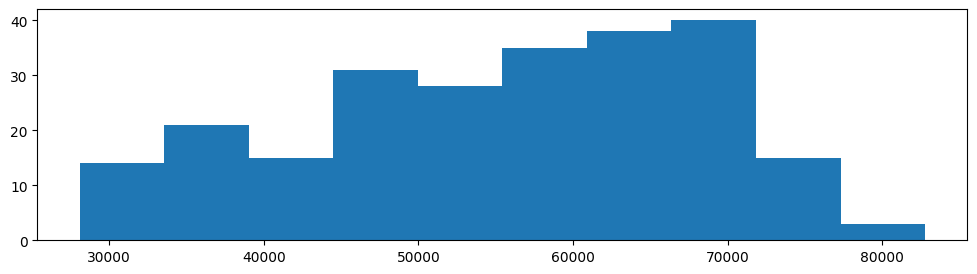

In [18]:
plt.figure(figsize=(12, 3))
plt.hist(subtask3)

# Submission

In [19]:
def build_df(sid, answers):
    return pd.DataFrame(
        {"SampleID": test_df_["SampleID"], "subtaskID": sid, "Answer": answers}
    )

subtasks = [("Task1", subtask1), ("Task2", subtask2), ("Task3", subtask3)]

submission_df = pd.concat(
    [
        build_df(sid, ans)
        for sid, ans in subtasks
    ]
)

In [20]:
submission_df.head()

,SampleID,subtaskID,Answer
0,1179,Task1,Incert
1,866,Task1,Autentic
2,102,Task1,Incert
3,440,Task1,Incert
4,59,Task1,Incert


In [21]:
submission_df.to_csv(f"{root_path}/submission.csv", index=False)